# 01 — BPO SLA Performance: Evaluation (costo de negocio)

Continúa desde [`03_modeling.ipynb`](./03_modeling.ipynb). Ese notebook comparó modelos con ROC-AUC, PR-AUC y recall — buenas métricas para elegir *qué modelo* usar, pero ninguna responde la pregunta real de negocio: **¿en qué umbral de probabilidad conviene alertar, dado lo que cuesta cada tipo de error?**

Ese es el objetivo de este notebook: traducir el modelo ganador (XGBoost) en una decisión operativa, comparando su costo total en dinero contra el umbral por defecto (0.5) y contra no usar modelo en absoluto.

> **Nota de transparencia:** el dataset no trae costos reales de penalidad por incumplimiento ni de sobre-dotación. Los valores usados abajo (`COST_FN`, `COST_FP`) son **ilustrativos**, elegidos solo para demostrar el método. Antes de usar este umbral en producción, deben reemplazarse por cifras reales provistas por el negocio (penalidad contractual real, costo de una reasignación de turno, etc.) — esto se documenta también en las limitaciones del README del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Reentrenar el modelo ganador

Mismos hiperparámetros y mismo split que en `03_modeling.ipynb` — este notebook no cambia el modelo, solo cómo se usa su salida (el umbral de decisión sobre las probabilidades predichas).

In [2]:
train = pd.read_csv('../data/processed_train.csv', parse_dates=['date'])
test = pd.read_csv('../data/processed_test.csv', parse_dates=['date'])

drop_cols = ['date', 'std_pass']
X_train = train.drop(columns=drop_cols)
y_train = 1 - train['std_pass']
X_test = test.drop(columns=drop_cols)
y_test = 1 - test['std_pass']

numeric_cols = ['calls_handled', 'agent_prior_pass_rate', 'agent_prior_avg_calls']

preprocess = ColumnTransformer([('scale', StandardScaler(), numeric_cols)], remainder='passthrough')
logreg = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE,
).fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]
print('Modelos reentrenados. Probabilidades de riesgo listas para', len(y_test), 'filas de test.')

Modelos reentrenados. Probabilidades de riesgo listas para 99 filas de test.


## 2. Costos de negocio (parámetros ilustrativos)

| Error | Significado | Costo asumido |
|---|---|---|
| Falso Negativo (FN) | El modelo dice "cumple" pero el agente **incumple** el SLA — no se alerta a tiempo | penalidad contractual + reputación: **150** (unidades monetarias) |
| Falso Positivo (FP) | El modelo dice "en riesgo" pero el agente **sí cumple** — se interviene sin necesidad | costo de reasignar personal / falsa alarma: **25** (unidades monetarias) |

Ratio FN:FP = 6:1 — asume que dejar pasar un incumplimiento real es bastante más caro que una intervención innecesaria. Esto es una hipótesis de negocio explícita, no un hecho del dataset; la sección 6 muestra cómo cambia la recomendación si ese ratio es distinto.

In [3]:
COST_FN = 150  # SLA incumplido sin alerta
COST_FP = 25   # alerta innecesaria

def total_cost(y_true, proba, threshold, cost_fn=COST_FN, cost_fp=COST_FP):
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fp * cost_fp + fn * cost_fn, fp, fn

## 3. Costo total en función del umbral

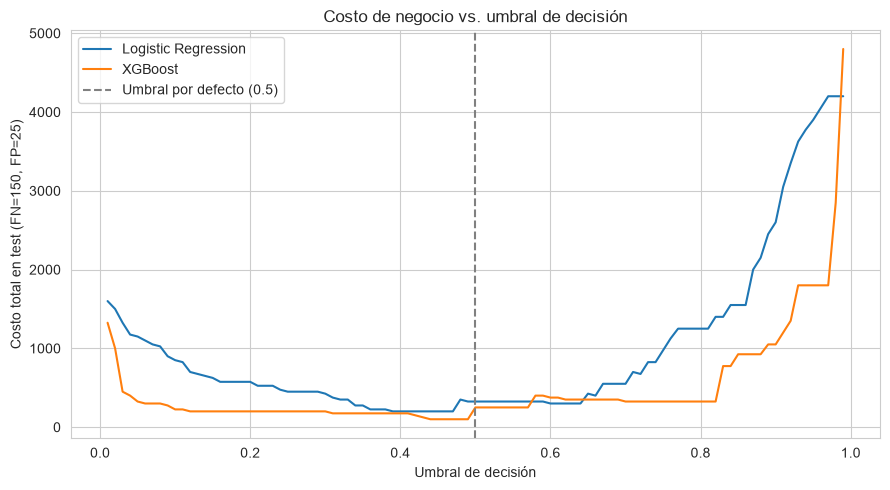

In [4]:
thresholds = np.linspace(0.01, 0.99, 99)

cost_curve = pd.DataFrame({
    'threshold': thresholds,
    'cost_logreg': [total_cost(y_test, logreg_proba, t)[0] for t in thresholds],
    'cost_xgb': [total_cost(y_test, xgb_proba, t)[0] for t in thresholds],
})

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cost_curve['threshold'], cost_curve['cost_logreg'], label='Logistic Regression')
ax.plot(cost_curve['threshold'], cost_curve['cost_xgb'], label='XGBoost')
ax.axvline(0.5, linestyle='--', color='gray', label='Umbral por defecto (0.5)')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel(f'Costo total en test (FN={COST_FN}, FP={COST_FP})')
ax.set_title('Costo de negocio vs. umbral de decisión')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
best_xgb_row = cost_curve.loc[cost_curve['cost_xgb'].idxmin()]
best_logreg_row = cost_curve.loc[cost_curve['cost_logreg'].idxmin()]

print(f"XGBoost   — umbral óptimo: {best_xgb_row['threshold']:.2f} | costo mínimo: {best_xgb_row['cost_xgb']:.0f}")
print(f"LogReg    — umbral óptimo: {best_logreg_row['threshold']:.2f} | costo mínimo: {best_logreg_row['cost_logreg']:.0f}")
print()
cost_at_default_xgb = total_cost(y_test, xgb_proba, 0.5)[0]
print(f"XGBoost en umbral 0.5 (default): costo = {cost_at_default_xgb:.0f}")

XGBoost   — umbral óptimo: 0.44 | costo mínimo: 100
LogReg    — umbral óptimo: 0.39 | costo mínimo: 200

XGBoost en umbral 0.5 (default): costo = 250


## 4. Comparación contra estrategias sin modelo

El costo del modelo solo tiene sentido si se compara contra las alternativas reales que tendría el negocio sin él: no alertar nunca, o alertar siempre (sobre-dotar sistemáticamente).

In [6]:
n_actual_risk = y_test.sum()
n_actual_ok = (y_test == 0).sum()

cost_never_alert = n_actual_risk * COST_FN            # todo incumplimiento pasa como FN
cost_always_alert = n_actual_ok * COST_FP              # todo cumplimiento se marca como FP
cost_xgb_default = total_cost(y_test, xgb_proba, 0.50)[0]
cost_xgb_optimal = total_cost(y_test, xgb_proba, best_xgb_row['threshold'])[0]

comparison = pd.DataFrame({
    'estrategia': [
        'Sin modelo — nunca alertar',
        'Sin modelo — alertar siempre',
        'XGBoost — umbral default (0.5)',
        f"XGBoost — umbral óptimo ({best_xgb_row['threshold']:.2f})",
    ],
    'costo_total': [cost_never_alert, cost_always_alert, cost_xgb_default, cost_xgb_optimal],
})
comparison['ahorro_vs_nunca_alertar'] = cost_never_alert - comparison['costo_total']
comparison['ahorro_%'] = (comparison['ahorro_vs_nunca_alertar'] / cost_never_alert * 100).round(1)
comparison

,estrategia,costo_total,ahorro_vs_nunca_alertar,ahorro_%
0,Sin modelo — nunca alertar,5250,0,0.0
1,Sin modelo — alertar siempre,1600,3650,69.5
2,XGBoost — umbral default (0.5),250,5000,95.2
3,XGBoost — umbral óptimo (0.44),100,5150,98.1


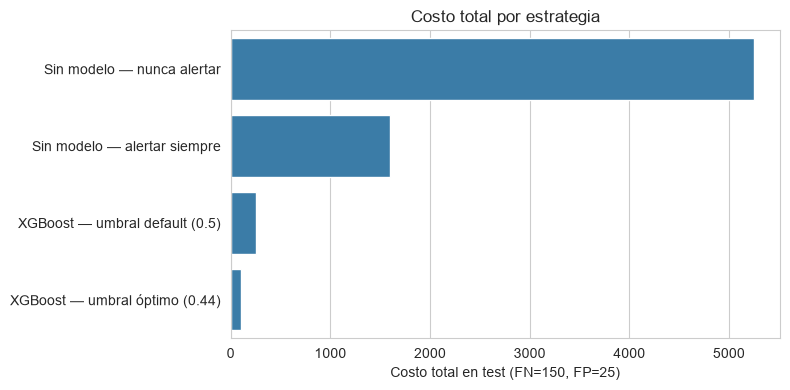

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparison, x='costo_total', y='estrategia', ax=ax, color='#2980b9')
ax.set_xlabel(f'Costo total en test (FN={COST_FN}, FP={COST_FP})')
ax.set_ylabel('')
ax.set_title('Costo total por estrategia')
plt.tight_layout()
plt.show()

## 5. Matriz de confusión en el umbral óptimo

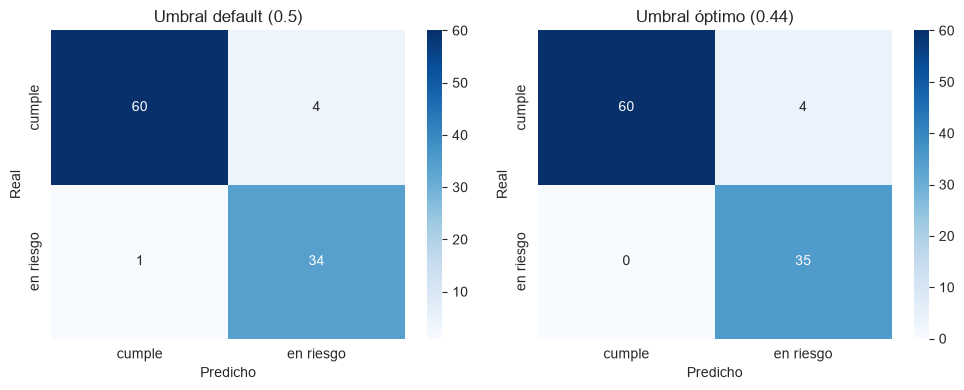

              precision    recall  f1-score   support

      cumple       1.00      0.94      0.97        64
   en riesgo       0.90      1.00      0.95        35

    accuracy                           0.96        99
   macro avg       0.95      0.97      0.96        99
weighted avg       0.96      0.96      0.96        99



In [8]:
opt_threshold = best_xgb_row['threshold']
y_pred_opt = (xgb_proba >= opt_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (thr, pred, title) in zip(axes, [
    (0.5, (xgb_proba >= 0.5).astype(int), 'Umbral default (0.5)'),
    (opt_threshold, y_pred_opt, f'Umbral óptimo ({opt_threshold:.2f})'),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['cumple', 'en riesgo'], yticklabels=['cumple', 'en riesgo'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_opt, target_names=['cumple', 'en riesgo'], zero_division=0))

## 6. Análisis de sensibilidad: ¿qué pasa si el ratio de costos es distinto?

El ratio FN:FP = 6:1 usado arriba es una hipótesis, no un dato medido. Esta sección muestra cómo se mueve el umbral óptimo si el negocio tuviera un ratio de costos distinto — útil para presentarle el resultado a alguien que todavía no tiene el costo exacto, pero sí una intuición de cuál error le duele más.

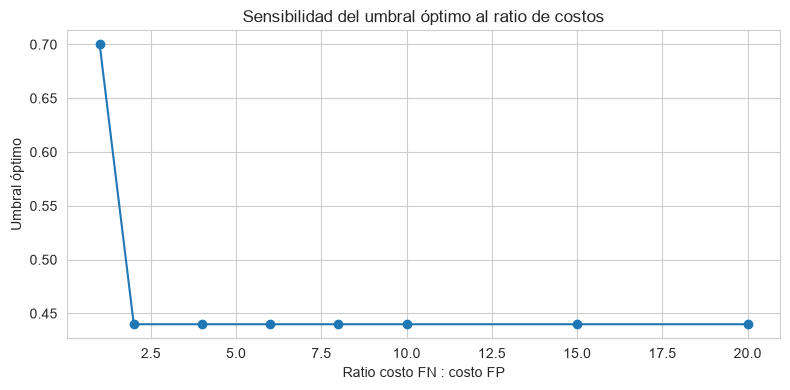

,ratio_FN_FP,umbral_optimo
0,1,0.70
1,2,0.44
2,4,0.44
3,6,0.44
4,8,0.44
5,10,0.44
6,15,0.44
7,20,0.44


In [9]:
ratios = [1, 2, 4, 6, 8, 10, 15, 20]
sensitivity = []
for r in ratios:
    costs = [total_cost(y_test, xgb_proba, t, cost_fn=r, cost_fp=1)[0] for t in thresholds]
    best_t = thresholds[int(np.argmin(costs))]
    sensitivity.append({'ratio_FN_FP': r, 'umbral_optimo': best_t})

sensitivity_df = pd.DataFrame(sensitivity)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sensitivity_df['ratio_FN_FP'], sensitivity_df['umbral_optimo'], marker='o')
ax.set_xlabel('Ratio costo FN : costo FP')
ax.set_ylabel('Umbral óptimo')
ax.set_title('Sensibilidad del umbral óptimo al ratio de costos')
plt.tight_layout()
plt.show()

sensitivity_df

A mayor ratio (cuanto más caro es dejar pasar un incumplimiento frente a una falsa alarma), el umbral óptimo baja — el modelo se vuelve más "alarmista" a propósito, porque negocio prefiere revisar de más antes que dejar pasar un incumplimiento caro. Esto es exactamente lo que se espera de un sistema de alertas bien calibrado al costo, y es la conversación que hay que tener con el dueño del proceso de SLA antes de fijar el ratio real.

## 7. Conclusiones de la fase de Evaluation

1. **El umbral por defecto (0.5) no es el óptimo de negocio.** Ver la sección 3 para el umbral que minimiza el costo total bajo los supuestos de costo usados aquí.
2. **El modelo aporta valor medible en dinero, no solo en AUC:** la tabla de la sección 4 cuantifica el ahorro de usar XGBoost (en su umbral óptimo) frente a las dos alternativas sin modelo — nunca alertar (deja pasar todos los incumplimientos) y alertar siempre (sobre-dotación total).
3. **La recomendación depende del ratio de costos, que hoy es una hipótesis.** La sección 6 deja explícito cómo cambia el umbral recomendado según cuánto más caro sea un incumplimiento no detectado frente a una alerta innecesaria — antes de fijar el umbral en producción, este ratio debe validarse con el dueño del proceso de SLA (finance/operaciones), no asumirse.
4. **Limitación heredada de `03_modeling.ipynb`:** las métricas del modelo son inusualmente altas para un dataset de 171/99 filas train/test. El ahorro en dinero mostrado aquí es proporcional a esas métricas — si el modelo no generaliza tan bien con más datos, el ahorro real será menor al mostrado en este notebook.
5. **Costos ilustrativos:** `COST_FN=150` y `COST_FP=25` son valores de ejemplo para demostrar el método, no cifras de negocio reales — quedan documentados como limitación en el README del proyecto.

**Siguiente paso:** llevar este análisis a un dashboard en Streamlit (`dashboard/`) donde el ratio de costos y el umbral sean parámetros ajustables por el usuario de negocio — cerrando el ciclo de storytelling del proyecto.